
<tr>
    <td><h1 style="text-align: left; font-size:300%;">
        ML2026 - Homework
    </h1></td>
    <div style="text-align: right">
    <b> Machine Learning 2026</b> <br>
    <td width="100px"> 
        
</tr>


### Packages

In [96]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [97]:
import numpy as np
np.random.seed(0)
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [98]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Task 1
_Perform preliminary analysis of the data. For instance, but not limited to, visualizing samples, identifying if features are correlated, determining which are most correlated with the target class, and inspecting the distribution of samples among classes. We want to recover the data for the Exit Rate variable. Train a regressor to predict this variable’s values given the remaining variables. Compare different regression algorithms for this task, and perform feature selection. Since this feature is also missing in the test set, use only the training data for this step and use robust evaluation techniques to compare algorithms._

**1.1 Preliminary Analysis of the data and Explorative analysis**

**1.2 Exit Rate Variable**


---
---

## 1.1 Preliminary analysis of the data

### Data preprocessing

In [99]:
data = pd.read_csv("data/online_shoppers_intention.csv")
train_data = pd.read_csv("data/training_set_online_shoppers_intention.csv")
test_data = pd.read_csv("data/test_set_online_shoppers_intention.csv")

In [100]:
data.head()
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,3837,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,7305,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


In [101]:
test_data.head()

,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


Since I want to remove unnamed column (ID perhaps):

In [102]:
train_data.drop(["Unnamed: 0"], inplace = True, axis = 1)
test_data.drop(["Unnamed: 0"], inplace = True, axis = 1)

In [103]:
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


## Descriptive Analysis

I want to explore the data types in my dataframe

In [104]:
exp_data = train_data.copy()
exp_data.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [105]:
exp_data.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Few columns must be categorical since treating these variables as integers would imply an order or a magnitude that does not exist in the real context.

categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
exp_data[categorical_columns] = exp_data[categorical_columns].astype("category")
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_dtype = pd.CategoricalDtype(categories=month_order, ordered=True)
exp_data['Month'] = exp_data['Month'].astype(month_dtype)

In [106]:
exp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9248 entries, 0 to 9247
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9248 non-null   int64  
 1   Administrative_Duration  9248 non-null   float64
 2   Informational            9248 non-null   int64  
 3   Informational_Duration   9248 non-null   float64
 4   ProductRelated           9248 non-null   int64  
 5   ProductRelated_Duration  9248 non-null   float64
 6   BounceRates              9248 non-null   float64
 7   ExitRates                6466 non-null   float64
 8   PageValues               9248 non-null   float64
 9   SpecialDay               9248 non-null   float64
 10  Month                    9248 non-null   object 
 11  OperatingSystems         9248 non-null   int64  
 12  Browser                  9248 non-null   int64  
 13  Region                   9248 non-null   int64  
 14  TrafficType             

In [107]:
exp_data.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,6466.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000
mean,2.303417,79.244607,0.502054,34.903589,31.695718,1183.552836,0.022647,0.042791,5.841185,0.062522,2.122837,2.362565,3.130623,4.038819
std,3.306724,172.311739,1.252054,140.233919,44.062244,1791.438690,0.049182,0.048164,18.448440,0.200413,0.900143,1.704494,2.388742,3.996985
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,183.612500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.000000,0.000000,0.000000,18.000000,593.399405,0.003279,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,91.000000,0.000000,0.000000,38.000000,1456.401191,0.017124,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,2720.500000,14.000000,2256.916667,584.000000,29970.465970,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Checking for NA in each column (axis=0)

In [108]:
np.sum(exp_data.isna(), axis=0)

Administrative                0
Administrative_Duration       0
Informational                 0
Informational_Duration        0
ProductRelated                0
ProductRelated_Duration       0
BounceRates                   0
ExitRates                  2782
PageValues                    0
SpecialDay                    0
Month                         0
OperatingSystems              0
Browser                       0
Region                        0
TrafficType                   0
VisitorType                   0
Weekend                       0
Revenue                       0
dtype: int64

In [109]:
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Month"]
corr = exp_data.drop(categorical_columns, axis=1).corr()
corr

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue
Administrative,1.000000,0.611851,0.375773,0.258137,0.419721,0.380945,-0.224850,-0.309846,0.094717,-0.102648,0.028321,0.134150
Administrative_Duration,0.611851,1.000000,0.289336,0.218854,0.259107,0.303871,-0.145781,-0.207051,0.067182,-0.080183,0.014885,0.091469
Informational,0.375773,0.289336,1.000000,0.616967,0.352429,0.377018,-0.116810,-0.156937,0.042454,-0.052272,0.034639,0.093716
Informational_Duration,0.258137,0.218854,0.616967,1.000000,0.266616,0.320617,-0.075360,-0.103809,0.028986,-0.032154,0.028703,0.066165
ProductRelated,0.419721,0.259107,0.352429,0.266616,1.000000,0.873362,-0.208201,-0.294423,0.053836,-0.032640,0.021780,0.162163
ProductRelated_Duration,0.380945,0.303871,0.377018,0.320617,0.873362,1.000000,-0.198554,-0.269676,0.055034,-0.045060,0.010219,0.164373
BounceRates,-0.224850,-0.145781,-0.116810,-0.075360,-0.208201,-0.198554,1.000000,0.912628,-0.121093,0.074986,-0.050657,-0.152728
ExitRates,-0.309846,-0.207051,-0.156937,-0.103809,-0.294423,-0.269676,0.912628,1.000000,-0.175136,0.107706,-0.069067,-0.208109
PageValues,0.094717,0.067182,0.042454,0.028986,0.053836,0.055034,-0.121093,-0.175136,1.000000,-0.064241,0.004976,0.485376
SpecialDay,-0.102648,-0.080183,-0.052272,-0.032154,-0.032640,-0.045060,0.074986,0.107706,-0.064241,1.000000,-0.017286,-0.082262


<Axes: >

Text(0.5, 1.0, 'Feature Correlation Matrix')

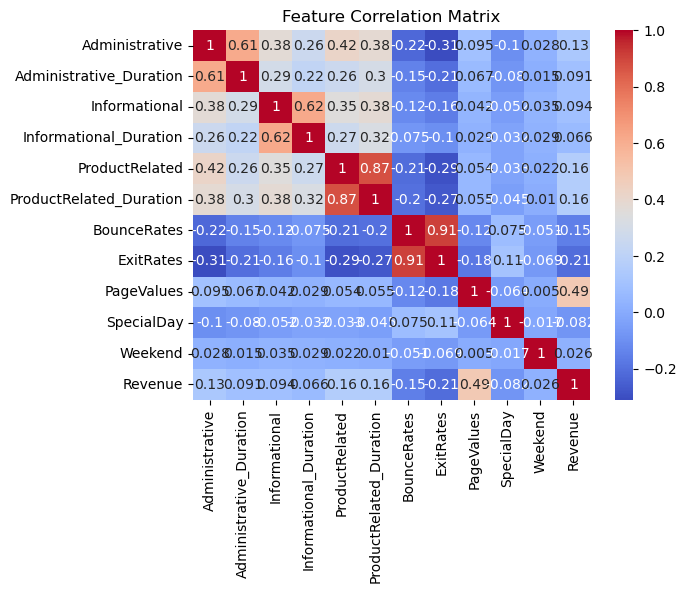

In [110]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Looking at the heat map, we can see that ``Revenue`` and ``PageValues`` seems to be moderately correlated. 
\
Other features the pairs ExitRate-BounceRate, ProductRelated-ProductRelated_Duration, Informational-Informational-Duration I mean are obviously correlated since they are referring to the same events

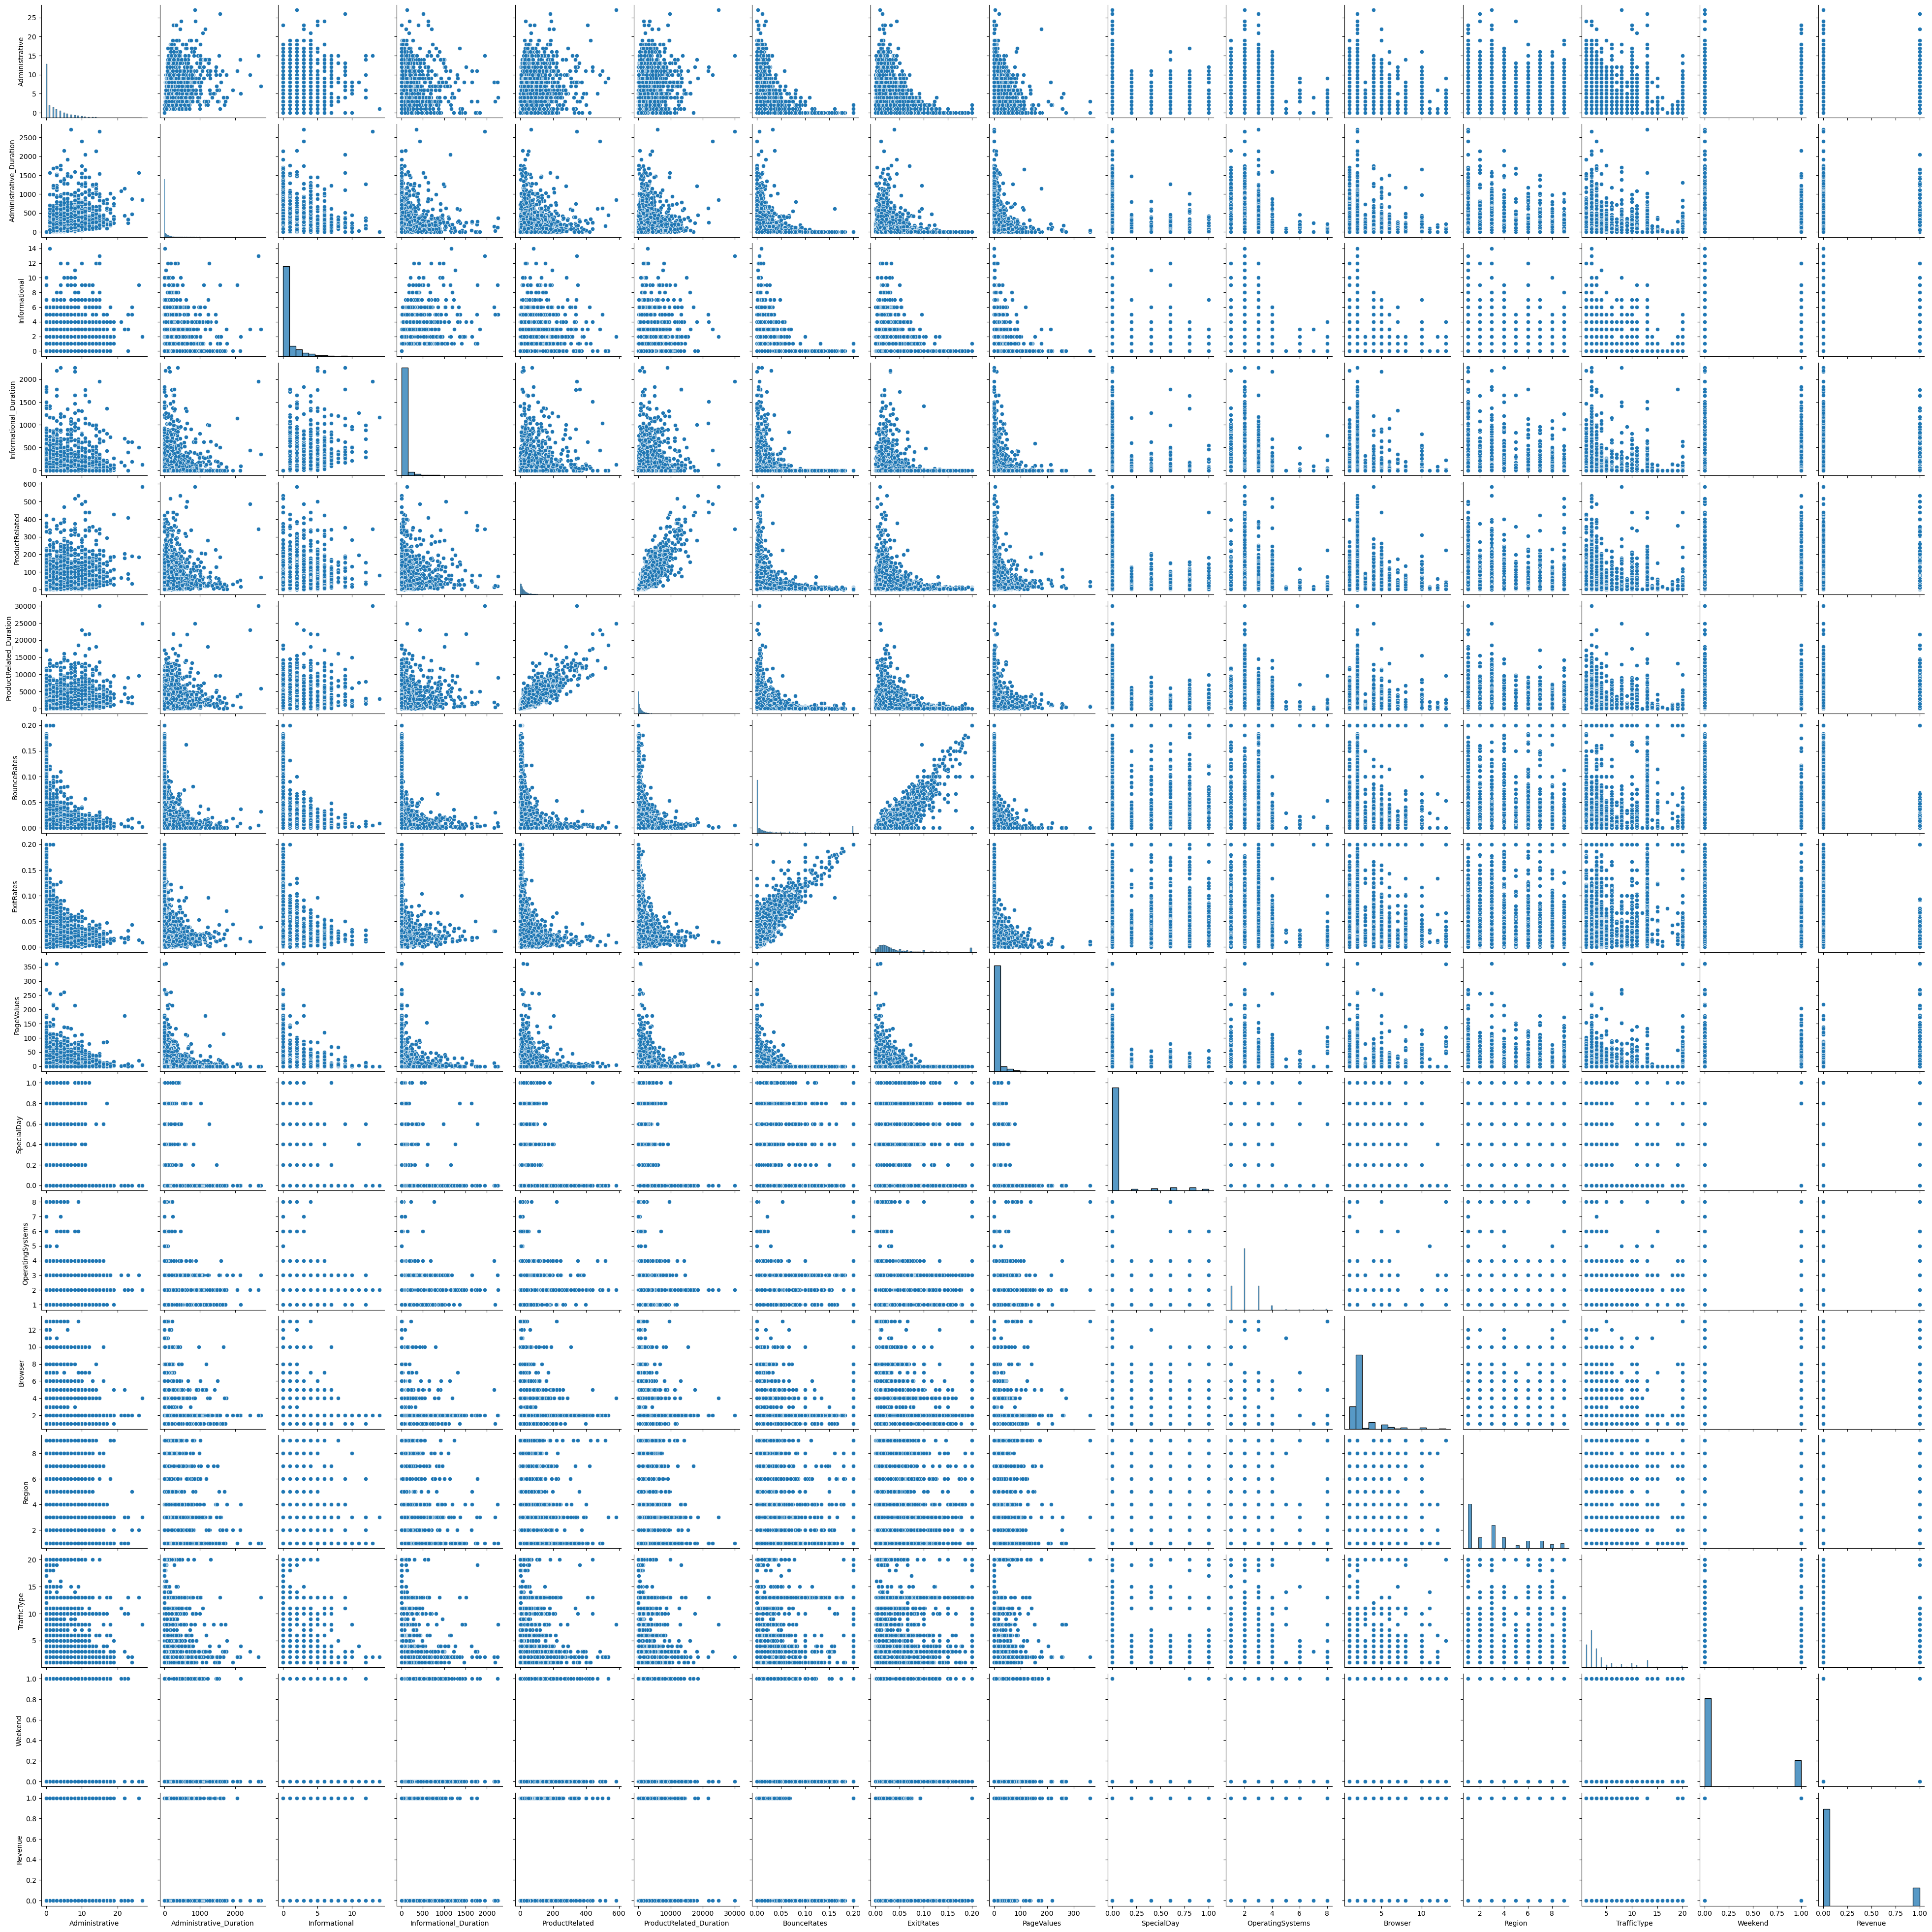

In [111]:
sns.pairplot(exp_data, height=2.5)
plt.show()

In [112]:
exp_data['Revenue'].value_counts()

Revenue
False    7807
True     1441
Name: count, dtype: int64

<Axes: xlabel='Revenue', ylabel='count'>

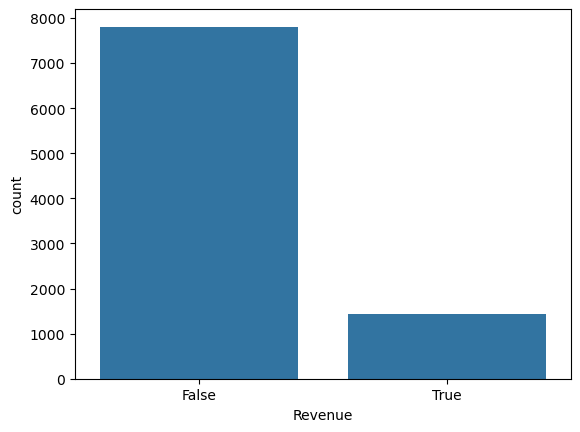

In [113]:
sns.countplot(x='Revenue', data=exp_data)
plt.show()

The target variable ``Revenue`` exhibits a clear class imbalance, with False representing the majority (7807 samples) and True the minority (1441 samples). Given this distribution, accuracy is not a reliable metric. Therefore, I will prioritize metrics like the F1-Score and utilize stratified splitting to maintain class proportions across training and test sets, ensuring the model is evaluated fairly on its ability to detect purchasing intent.

## Distribution of Features

### Categorical Variables

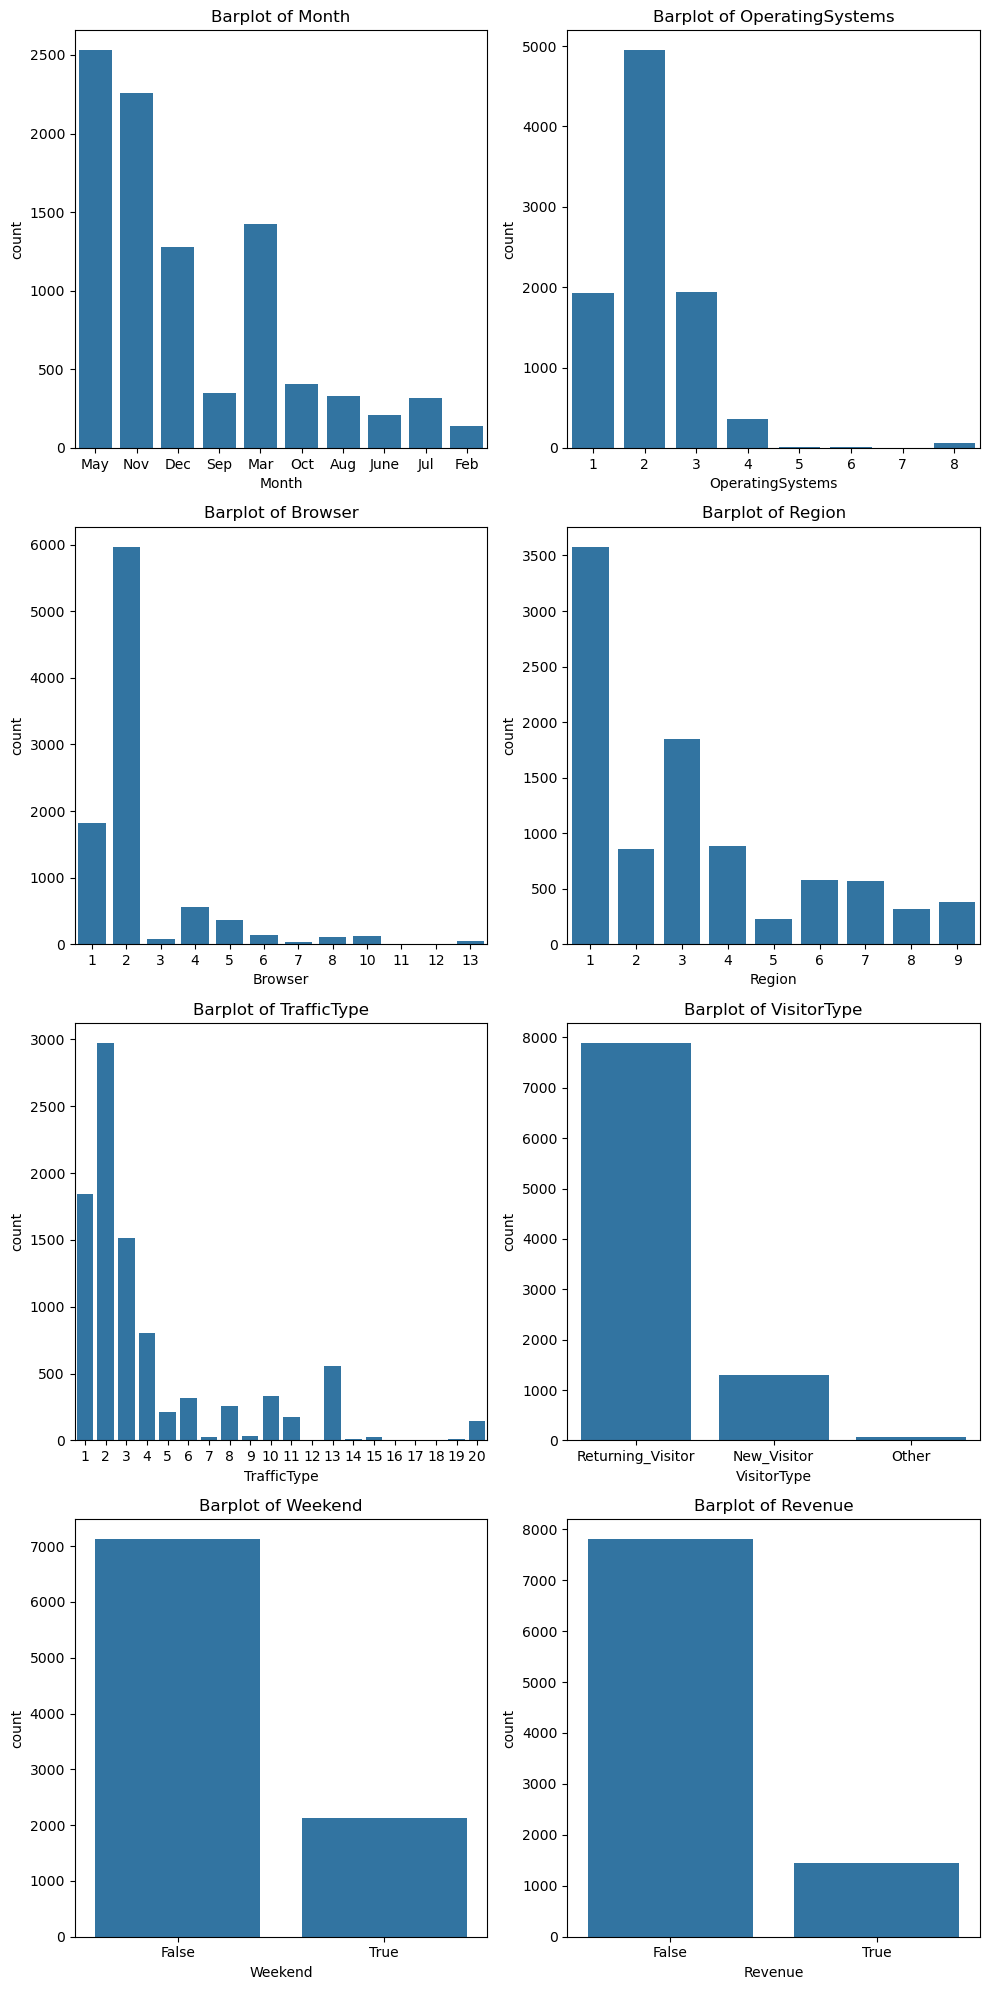

In [114]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 20))
categoricals = ['Month','OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType','Weekend', 'Revenue']
for name in enumerate(categoricals):
    i, name = name
    sns.countplot(data=exp_data, x=name, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title("Barplot of {}".format(name))

plt.tight_layout()
plt.show();

### Continuous Features

<Axes: xlabel='Revenue', ylabel='Administrative'>

Text(0.5, 1.0, 'Boxplot of Administrative')

<Axes: xlabel='Revenue', ylabel='Administrative_Duration'>

Text(0.5, 1.0, 'Boxplot of Administrative_Duration')

<Axes: xlabel='Revenue', ylabel='Informational'>

...

Text(0.5, 1.0, 'Boxplot of BounceRates')

<Axes: xlabel='Revenue', ylabel='ExitRates'>

Text(0.5, 1.0, 'Boxplot of ExitRates')

<Axes: xlabel='Revenue', ylabel='PageValues'>

Text(0.5, 1.0, 'Boxplot of PageValues')

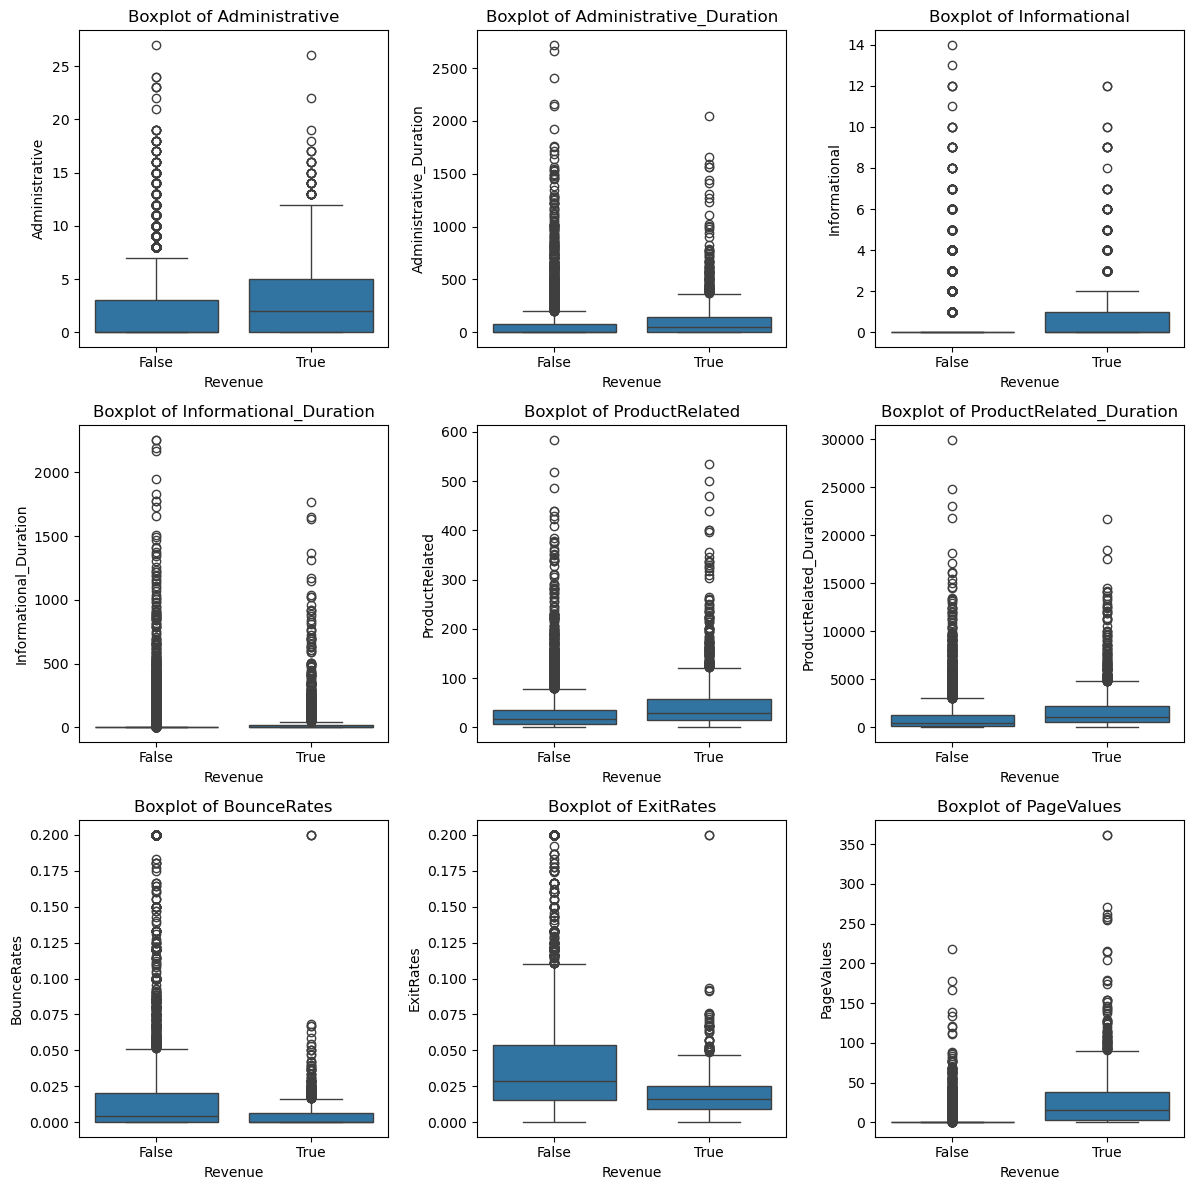

In [115]:
#boxplot a continuos variable and consider if it has outliers and everything: 
continuous = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4)

for i, name in enumerate(continuous):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.boxplot(data=exp_data, x="Revenue", y=name, ax=ax)
    ax.set_title("Boxplot of {}".format(name))

plt.tight_layout()
plt.show()

<Axes: xlabel='Administrative', ylabel='Count'>

Text(0.5, 1.0, 'Administrative')

<Axes: xlabel='Administrative_Duration', ylabel='Count'>

Text(0.5, 1.0, 'Administrative_Duration')

<Axes: xlabel='Informational', ylabel='Count'>

...

Text(0.5, 1.0, 'BounceRates')

<Axes: xlabel='ExitRates', ylabel='Count'>

Text(0.5, 1.0, 'ExitRates')

<Axes: xlabel='PageValues', ylabel='Count'>

Text(0.5, 1.0, 'PageValues')

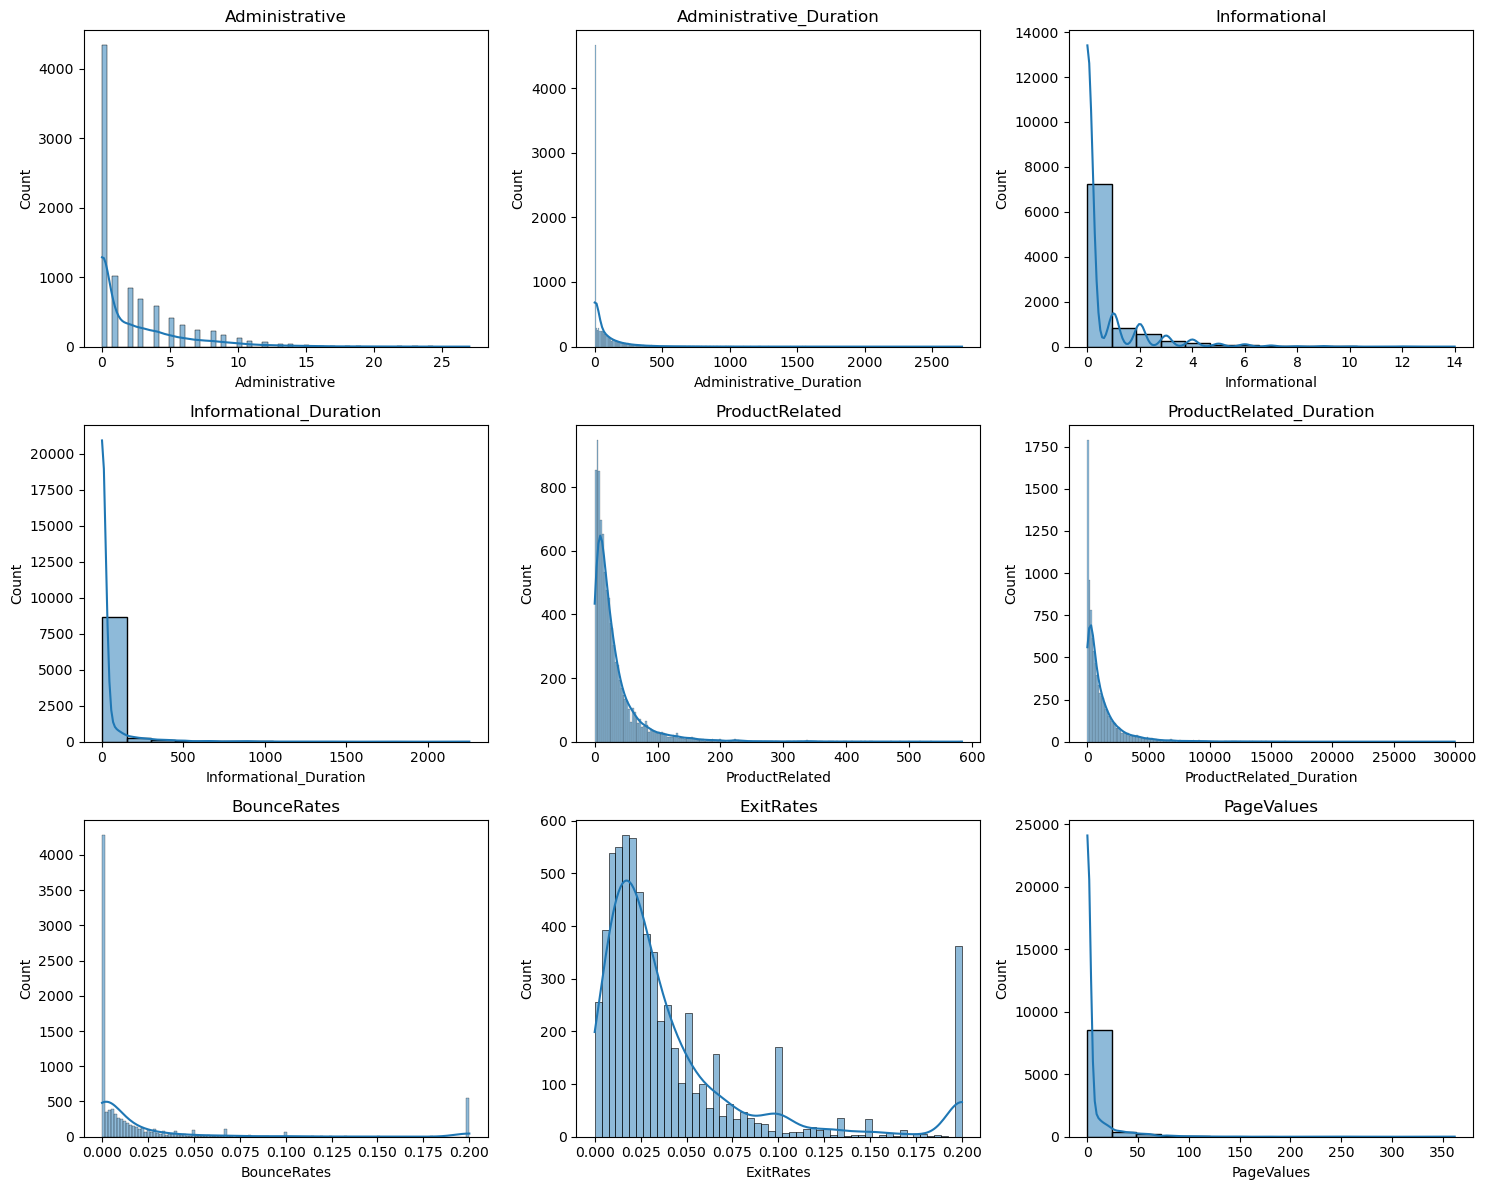

In [116]:
#distribution for the continous feature
cont_cols = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 
             'ProductRelated_Duration', 'BounceRates', 'ExitRates', 
             'PageValues']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), cont_cols):
    sns.histplot(train_data[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

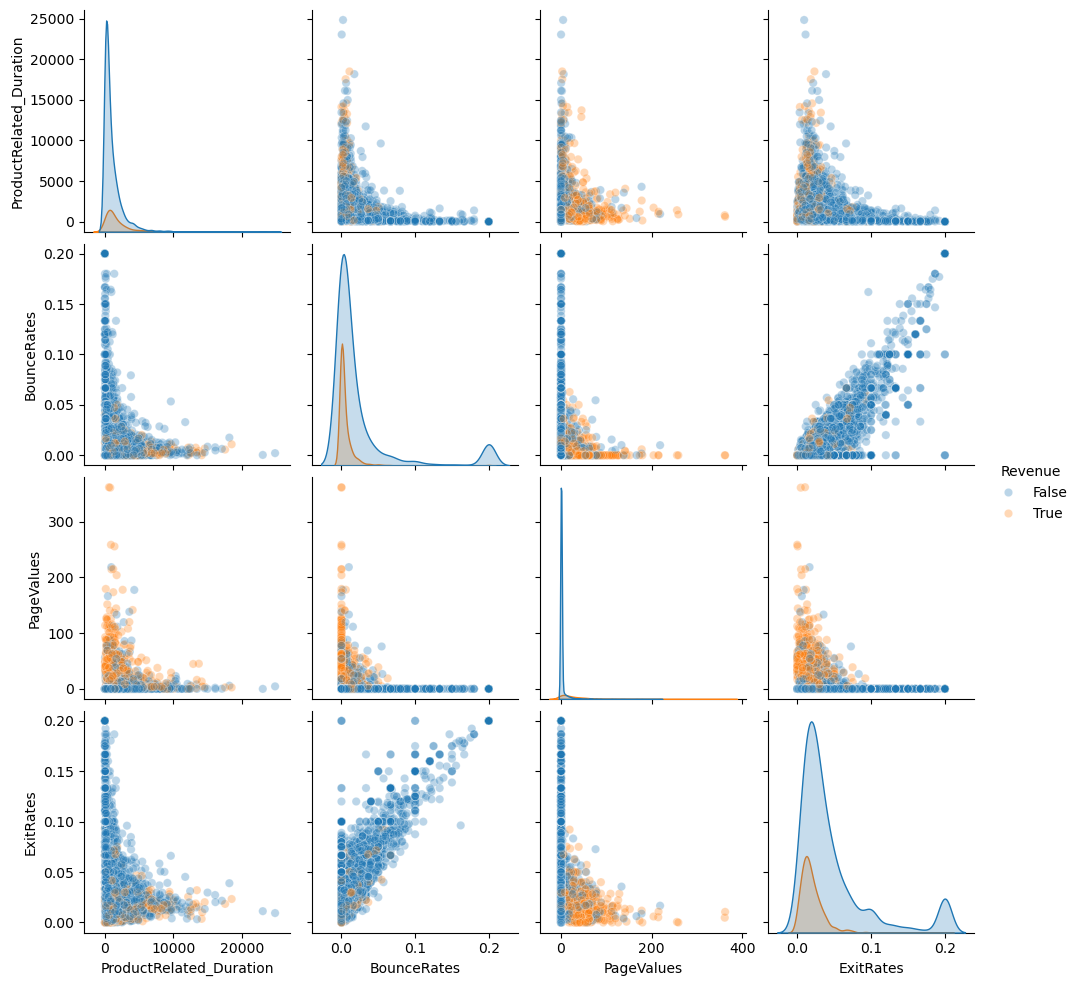

In [117]:
subset = ['ProductRelated_Duration', 'BounceRates', 'PageValues', 'ExitRates', 'Revenue']
sns.pairplot(train_data[subset].dropna(), hue='Revenue', diag_kind='kde', plot_kws={'alpha':0.3})
plt.show()

#as expected highly correalted variable have a lienar relationshiè 

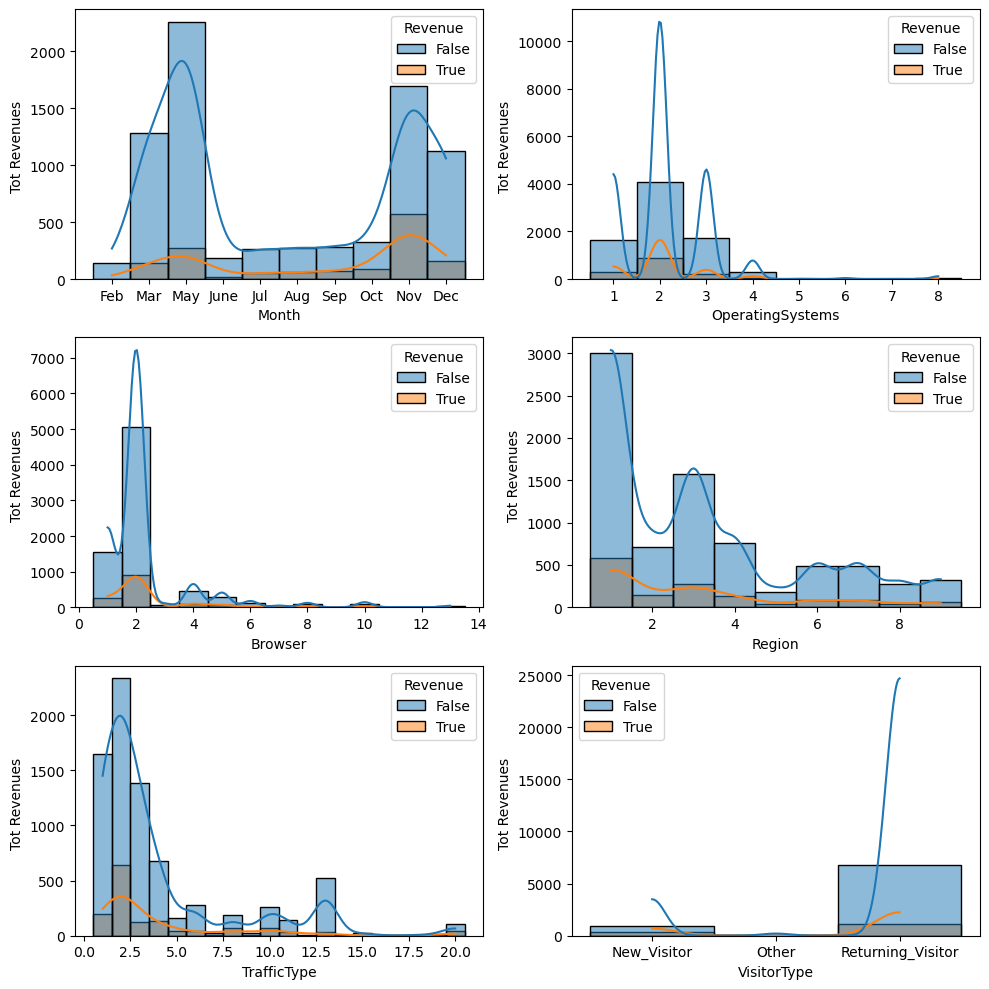

In [118]:
#some barplots for the total number of revenues (total number of true and false revenues) in the different categorical data: 
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
train_data[categorical_columns] = train_data[categorical_columns].astype("category")
# COLONNE DA METTERE COME CATEGORICHE: Operating System, Browser, Region, Traffic Type, Visitor Type
# Columns month to be set as an ordered category
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_dtype = pd.CategoricalDtype(categories=month_order, ordered=True)
train_data['Month'] = train_data['Month'].astype(month_dtype)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

categoricals = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]

for i, categorical in enumerate(categoricals):
    ax = axes[i // 2, i % 2]  # Assign the correct axes to 'ax'
    sns.histplot(data=train_data, x=categorical, hue="Revenue", kde=True, ax=ax)
    ax.set_xlabel(categorical)
    ax.set_ylabel("Tot Revenues ")

plt.tight_layout()
plt.show();

---
---

## 1.2 Exit Rate Variable

How many missing values do I have in my training set and in my test set?

## Encoding

In [120]:
train_data = pd.read_csv("data/training_set_online_shoppers_intention.csv")
test_data = pd.read_csv("data/test_set_online_shoppers_intention.csv")

#For TRAINING set
#one-hot encoing for 'Month'
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "June": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
} 
train_data['Month'] = train_data['Month'] .map(month_map)
train_data = pd.get_dummies(train_data, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType"])
train_data["Revenue"] = train_data["Revenue"].astype(int)
train_data["Weekend"] = train_data["Weekend"].astype(int)
train_data["month_sin"] = np.sin(2 * np.pi * train_data['Month'] / 12)
train_data["month_cos"] = np.cos(2 * np.pi * train_data['Month'] / 12)


test_data['Month'] = test_data['Month'] .map(month_map)
test_data = pd.get_dummies(test_data, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType"])
test_data["Revenue"] = test_data["Revenue"].astype(int)
test_data["Weekend"] = test_data["Weekend"].astype(int)
test_data["month_sin"] = np.sin(2 * np.pi * test_data['Month'] / 12)
test_data["month_cos"] = np.cos(2 * np.pi * test_data['Month'] / 12)

In [122]:
#re-allinging the column for the test set 
#saving the columns
train_cols = train_data.columns
#reallining: 
test_data = test_data.reindex(columns=train_cols, fill_value=0)

In [125]:
train_data.isna().sum().sort_values(ascending=False)
test_data.isna().sum().sort_values(ascending=False)

train_data.columns

ExitRates        2782
TrafficType_1       0
TrafficType_7       0
TrafficType_6       0
TrafficType_5       0
                 ... 
Browser_8           0
Browser_10          0
Browser_11          0
Browser_12          0
month_cos           0
Length: 68, dtype: int64

ExitRates        917
TrafficType_1      0
TrafficType_7      0
TrafficType_6      0
TrafficType_5      0
                ... 
Browser_8          0
Browser_10         0
Browser_11         0
Browser_12         0
month_cos          0
Length: 68, dtype: int64

Index(['Unnamed: 0', 'Administrative', 'Administrative_Duration',
       'Informational', 'Informational_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
       'SpecialDay', 'Month', 'Weekend', 'Revenue', 'OperatingSystems_1',
       'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_4',
       'OperatingSystems_5', 'OperatingSystems_6', 'OperatingSystems_7',
       'OperatingSystems_8', 'Browser_1', 'Browser_2', 'Browser_3',
       'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7', 'Browser_8',
       'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13', 'Region_1',
       'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6', 'Region_7',
       'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_2',
       'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6',
       'TrafficType_7', 'TrafficType_8', 'TrafficType_9', 'TrafficType_10',
       'TrafficType_11', 'TrafficType_12', 'TrafficType_13',

---

### Regression

To predict ``ExitRates`` missing values, we trained different regression algorithms:
- Linear regression
- Ridge
- Forward Feature Selection
- Lasso
- Random Forest

Hyper parameter tuning only for best regressor?
PS no need per reindexing in caso perchè precedentemente ottenuti dai dummy già allineati

In [126]:
copied_train = train_data[train_data['ExitRates'].notna()]

In [129]:
X = copied_train.drop(['ExitRates', 'Revenue'], axis=1)
y = copied_train['ExitRates']

print(X.columns)

Index(['Unnamed: 0', 'Administrative', 'Administrative_Duration',
       'Informational', 'Informational_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'PageValues', 'SpecialDay',
       'Month', 'Weekend', 'OperatingSystems_1', 'OperatingSystems_2',
       'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5',
       'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8',
       'Browser_1', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5',
       'Browser_6', 'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11',
       'Browser_12', 'Browser_13', 'Region_1', 'Region_2', 'Region_3',
       'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9',
       'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4',
       'TrafficType_5', 'TrafficType_6', 'TrafficType_7', 'TrafficType_8',
       'TrafficType_9', 'TrafficType_10', 'TrafficType_11', 'TrafficType_12',
       'TrafficType_13', 'TrafficType_14', 'Traf

In [131]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer

r2_score = make_scorer(r2_score, greater_is_better=True)
mean_squared_error = make_scorer(mean_squared_error, greater_is_better=True)


results = {}

### Multiple regression

In [132]:
from sklearn.linear_model import LinearRegression 

MultipleRegression = LinearRegression(fit_intercept= True)
scores_MR = cross_val_score(MultipleRegression, X, y, cv = 5, scoring=mean_squared_error)
scores_MR
results['MultipleRegression'] = (float(scores_MR.mean().round(4)), float(scores_MR.std().round(4)))

array([0.00040461, 0.00030392, 0.00032619, 0.00031143, 0.00027047])

### Forward Feature Selection

In [133]:
#2.forward feature selection
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    MultipleRegression,
    n_features_to_select= 'auto',       
    direction="forward",
    scoring= mean_squared_error,                  
    cv=5,                          
    n_jobs=-1                       
)

sfs_forward.fit(X, y)
selected_mask = sfs_forward.get_support()
selected_indices = np.where(selected_mask)[0]

print(selected_indices)

SequentialFeatureSelector(estimator=LinearRegression(), n_jobs=-1,
                          scoring=make_scorer(mean_squared_error, response_method='predict'))

[16 18 19 22 23 24 25 26 27 29 30 31 32 33 34 35 36 37 38 39 40 46 47 49
 50 51 52 54 56 57 58 59 60]


### Lasso

In [134]:
#3.Lasso:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42))
])

param_grid = {
    'lasso__alpha': np.logspace(-4, 1, 50)
}

# Inner CV: seleziona il miglior alpha
grid_lasso = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)

# Outer CV: valuta le performance in modo onesto (nested CV)
scores_lasso = cross_val_score(grid_lasso, X, y, cv=5, scoring= mean_squared_error)
results['Lasso'] = (float(scores_lasso.mean().round(4)), float(scores_lasso.std().round(4)))

### Ridge Regression

In [135]:
#4. Ridge Regression
from sklearn.linear_model import Ridge


pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=42))
])

param_grid_ridge = {
    'ridge__alpha': np.logspace(-4, 1, 50)
}

# Inner CV: seleziona il miglior alpha
grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)

# Outer CV: valuta le performance in modo onesto (nested CV)
scores_ridge = cross_val_score(grid_ridge, X, y, cv=5, scoring=mean_squared_error)
results['Ridge'] = (float(scores_ridge.mean().round(4)), float(scores_ridge.std().round(4)))

### Random Forest

In [136]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)
scores_rf = cross_val_score(
    grid_rf,
    X,
    y,
    cv=5,
    scoring= mean_squared_error
)

results['RandomForest'] = (
    float(scores_rf.mean().round(4)),
    float(scores_rf.std().round(4))
)

Text(0, 0.5, 'Mean Squared Error')

Text(0.5, 1.0, 'Confronto modelli: MSE (mean ± std)')

[Text(0, 0, 'MultipleRegression'),
 Text(1, 0, 'Lasso'),
 Text(2, 0, 'Ridge'),
 Text(3, 0, 'RandomForest')]

Text(0.0, 0.0003, '0.0003')

Text(1.0, 0.0023, '0.0023')

Text(2.0, 0.0003, '0.0003')

Text(3.0, 0.0002, '0.0002')

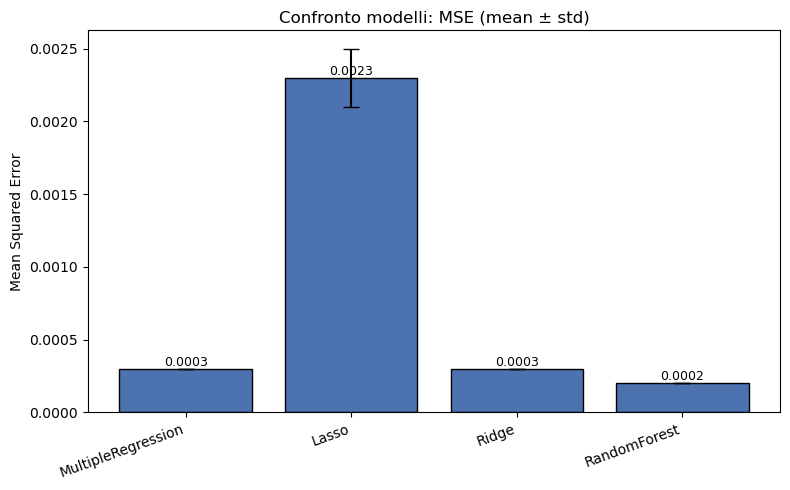

In [137]:
#results for regression algorithms:
keys = list(results.keys())
means = [v[0] for v in results.values()]
stds = [v[1] for v in results.values()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(keys, means, yerr=stds, capsize=6, color="#4C72B0", edgecolor="black")

ax.set_ylabel("Mean Squared Error")
ax.set_title("Confronto modelli: MSE (mean ± std)")
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=20, ha="right")

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{mean:.4f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("mse_barplot.png", dpi=150)
plt.show()


#the random forest seems to work pretty well compare to the others so we will process to fill the NaN 
#the only drawback for the random forest approch is to not be so clear to understand how it works but we will use it for prediction so we are more concearned about precision in the prediction
#so we choose the one with the lowerest mean squared error and std in the model tested!

----
---
---

# Task 2
_Use the regression model trained at the previous step to recover the Exit Rate by predicting its value for each missing sample on the train and test set. Build a classification model to predict whether an online shopper is likely to make a purchase. Perform feature selection, compare different algorithms, and identify the one that works the best on this dataset. Finally, test the best algorithm’s performance on the provided test set. Determine whether a model built using the Exit Rate information is better than a model built using the remaining features._

**2.1 Recovering ExitRates** \
**2.2 Classification (with and without feature selection)** \
**2.3 Feature selection**:
- Logistic lasso 

**2.4 Performance on test set**

## 2.1 Filling NAs 

## Feature set

In [138]:
X_train_full = df_train_encoded.drop(columns=['Revenue'])
y_train_full = df_train_encoded['Revenue']

X_test_full = df_test_encoded.drop(columns=['Revenue'])
y_test_full = df_test_encoded['Revenue']

print(y_train_full.value_counts(normalize=True))  # reminder: check imbalance

NameError: name 'df_train_encoded' is not defined

Exception ignored in: <function ResourceTracker.__del__ at 0x1049e5d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1061d1d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106e9dd00>
Traceback (most recent call last

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'LDA': LinearDiscriminantAnalysis(priors=[0.5, 0.5]),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),
    'SVM': SVC(class_weight='balanced', probability=True),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

clf_results = {}

for name, model in clf_models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_validate(pipe, X_train_full, y_train_full, cv=skf, scoring=scoring)
    clf_results[name] = {metric: scores[f'test_{metric}'].mean() for metric in scoring}

clf_results_df = pd.DataFrame(clf_results).T
print(clf_results_df)

                     accuracy  precision    recall        f1   roc_auc
Logistic Regression  0.841479   0.494326  0.752953  0.596809  0.897596
LDA                  0.876082   0.600276  0.616232  0.607837  0.893583
QDA                  0.376948   0.193115  0.943096  0.320570  0.772956
SVM                  0.844724   0.501305  0.714067  0.588979  0.882848


## Feature selection!

In [ ]:
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_clf.fit(X_train_full, y_train_full)

importances_clf = pd.Series(rf_clf.feature_importances_, index=X_train_full.columns).sort_values(ascending=False)
print(importances_clf)

selector = SelectFromModel(rf_clf, threshold='median', prefit=True)
X_reg_selected = selector.transform(X_train_full)

selected_features = X_train_full.columns[selector.get_support()]
print("Selected features:", list(selected_features))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

PageValues                 0.322144
ExitRates                  0.098215
ProductRelated_Duration    0.080874
ProductRelated             0.067352
BounceRates                0.053304
                             ...   
TrafficType_19             0.000007
TrafficType_16             0.000003
OperatingSystems_7         0.000002
TrafficType_12             0.000001
TrafficType_17             0.000000
Length: 73, dtype: float64
Selected features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend', 'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3', 'Browser_1', 'Browser_2', 'Browser_4', 'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_6', 'Region_7', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_8', 'VisitorType_New_Visitor', 'VisitorType_Returning_Visitor', 'Month_Dec', 'Month_Jul', 'Month_Ma

/opt/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


## Performance on test set

In [ ]:
best_model = RandomForestClassifier(random_state=42, class_weight='balanced')  # example — use whichever won
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

best_pipe.fit(X_train_full[selected_features], y_train_full)

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = best_pipe.predict(X_test_full[selected_features])
y_proba = best_pipe.predict_proba(X_test_full[selected_features])[:, 1]

print(classification_report(y_test_full, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_full, y_proba))
print(confusion_matrix(y_test_full, y_pred))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


              precision    recall  f1-score   support

       False       0.92      0.97      0.95      2615
        True       0.79      0.54      0.64       467

    accuracy                           0.91      3082
   macro avg       0.86      0.76      0.79      3082
weighted avg       0.90      0.91      0.90      3082

ROC-AUC: 0.9304707235885866
[[2548   67]
 [ 216  251]]


### No exit rate

In [ ]:
X_train_no_exit = df_train_encoded.drop(columns=['ExitRates'])
y_train_no_exit = df_train_encoded['ExitRates']

X_test_no_exit = df_test_encoded.drop(columns=['ExitRates'])
y_test_no_exit = df_test_encoded['ExitRates']

# Repeat Step 3's CV comparison and Step 5's test evaluation using X_train_no_exit / X_test_no_exit
# Then put the two result tables side by side and compare metrics directly

---
---
---

# Task 3 
_Repeat the analysis done at step 2 with clustering-based algorithms; compare the performance with respect to the best classification model_

I guess we have to predict ``Revenue`` but using clustering. 